# Choosing warm-up length

A suitable length for the warm-up period can be determined using the **time series inspection approach**. This involves looking at performance measures over time to identify when the system is exhibiting **steady state behaviour** (even though the system will never truly reach a "steady state").

If we simply plot the mean result at regular intervals, this would vary too much. Therefore, we plot the **cumulative mean** of the performance measure, and look for the point at which this **smoothes out and stabilises**. This indicates the point for the warm-up period to end.

This should be assessed when running the model using the base case parameters. If these change, you should reassess the appropriate warm-up period.

We should:

* Run the model with **multiple replications** (e.g. at least five).
* Use a **long run length** (i.e. 5-10 times actual planned run length).

The run time is provided at the end of the notebook.

Credit:

* Code for choice of warm-up period was adapted from Tom Monks (2024) [HPDM097 - Making a difference with health data](https://github.com/health-data-science-OR/stochastic_systems) (MIT Licence).

## Set-up

Load required packages.

In [1]:
# pylint: disable=missing-module-docstring,redefined-outer-name
# To ensure any updates to `simulation/` are fetched without needing to restart
# the notebook environment, reload `simulation/` before execution of each cell
%load_ext autoreload
%autoreload 1
%aimport simulation

In [2]:
# pylint: disable=wrong-import-position
import os
import time

import pandas as pd
import plotly.express as px
import plotly.io as pio

from simulation import Model, Param, WarmupAuditor

Display plotly express figures as non-interactive figures. This means they will be visible when browsing the notebooks on GitHub. To switch these back to interactive figures, simply remove this line.

In [3]:
pio.renderers.default = "svg"

Start timer.

In [4]:
notebook_start_time = time.time()

Define path to outputs folder

In [5]:
# pylint: disable=duplicate-code
OUTPUT_DIR = "../outputs/"

## Run model with auditor

In [6]:
def run_warmup_analysis(
    audit_interval, data_collection_period, number_of_runs
):
    """
    Runs the model without a warm-up, collecting performance measures at
    regular intervals, used to determine appropriate length of warm-up.

    Parameters
    ----------
    audit_interval : int
        Audit frequency (minutes).
    data_collection_period : int
        Duration of the data collection period (minutes).
    number_of_runs : int
        The number of runs (i.e., replications).

    Returns
    -------
    pd.DataFrame
        Combined results from all replications.
    """
    # Fixed set of parameters for all runs
    # Important: Sets warm-up period to zero
    param = Param(
        warm_up_period=0,
        data_collection_period=data_collection_period
    )
    # Store results from each replication
    all_dfs = []
    # Loop through replications
    for run in range(number_of_runs):
        # Run model with auditor
        model = Model(param=param, run_number=run)
        auditor = WarmupAuditor(model=model, interval=audit_interval)
        auditor.run()
        # Convert the run's audit results to DataFrame
        run_df = pd.DataFrame(auditor.audit_results)
        run_df["run"] = run
        all_dfs.append(run_df)
    # Combine all runs into a single DataFrame
    return pd.concat(all_dfs, ignore_index=True)

In [7]:
audit_results = run_warmup_analysis(
    audit_interval=400,
    data_collection_period=100000,
    number_of_runs=5
)
audit_results.head()

,time,wait_time,time_in_system,queue_length,utilisation,patients_in_system,run
0,0,NaN,NaN,0.000000,0.000000,0.000000,0
1,400,0.000000,10.169704,0.000000,0.482600,2.413000,0
2,800,0.572964,9.900665,0.143241,0.458219,2.434336,0
3,1200,0.474120,9.718395,0.119715,0.468875,2.464088,0
4,1600,0.431583,9.688721,0.113291,0.484050,2.533540,0


## Plot the results for time series inspection

In [8]:
def plot_time_series(
    audit_results, metric, file, warmup_time=None, path=OUTPUT_DIR
):
    """
    Plot cumulative mean trajectories and compute overall cumulative mean.

    Parameters
    ----------
    audit_results : pd.DataFrame
        Audit results, where columns include "time", "run" and the
        chosen metric like "wait_time" or "time_in_system".
    metric : str
        The performance measure to visualise.
    file : str
        Filename to save figure to.
    warmup_time : int
        The time point at which to display a vertical dashed line marking the
        suggested warm-up period.
    path : str
        Path to save file to (exc. filename)

    Returns
    -------
    plotly.graph_objects.Figure
        A Plotly Figure object containing cumulative mean trajectories for
        each run and the overall cumulative mean.
    """
    # Computer overall cumulative mean
    df = audit_results.groupby("time")[metric].mean().reset_index()
    df["overall_cumulative"] = df[metric].expanding().mean()

    # Plot cumulative mean for each run
    fig = px.line(
        data_frame=audit_results,
        x="time",
        y=metric,
        line_group="run"
    )
    fig.update_traces(line_color="lightblue")

    # Overlay overall cumulative mean
    overall_fig = px.line(df, x="time", y="overall_cumulative")
    fig.add_traces(list(overall_fig.select_traces()))

    # Add warm-up line
    if warmup_time:
        fig.add_vline(x=warmup_time, line_color="red", line_dash="dash",
                      annotation_text="Suggested warm-up",
                      annotation_font_color="red",
                      annotation_position="top right")

    # Axis labels and layout
    fig.update_layout(
        xaxis_title="Run time (minutes)",
        yaxis_title=f"Cumulative mean {metric.replace("_", " ")}",
        template="plotly_white"
    )

    # Save figure
    fig.write_image(os.path.join(path, file))

    # Display figure
    fig.show()

We've add a line to the point where it appears to reach a steady state - this is a subjective choice but here, for example, we could select **7 days** (1440*7=10080 minutes).

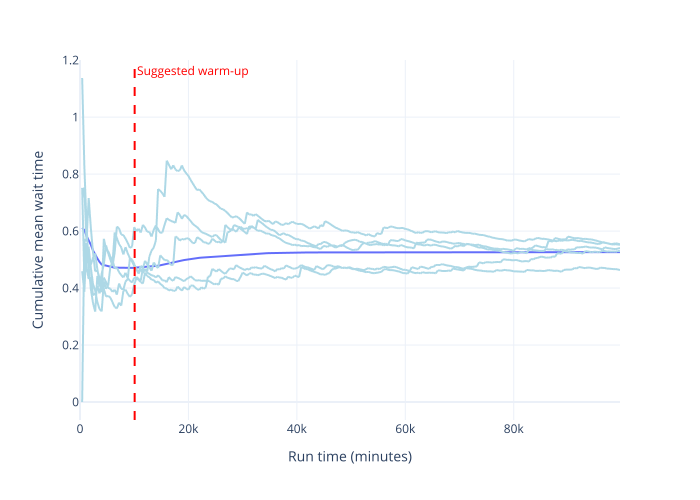

In [9]:
plot_time_series(
    audit_results=audit_results,
    metric="wait_time",
    file="choose_warmup_wait_time.png",
    warmup_time=10080
)

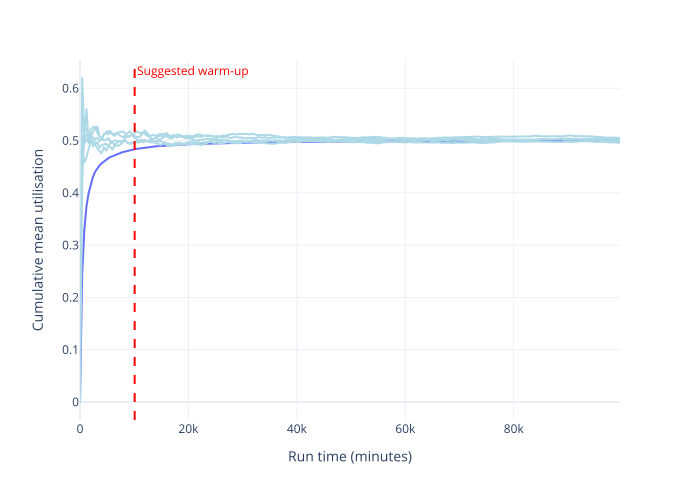

In [10]:
plot_time_series(
    audit_results=audit_results,
    metric="utilisation",
    file="choose_warmup_utilisation.png",
    warmup_time=10080
)

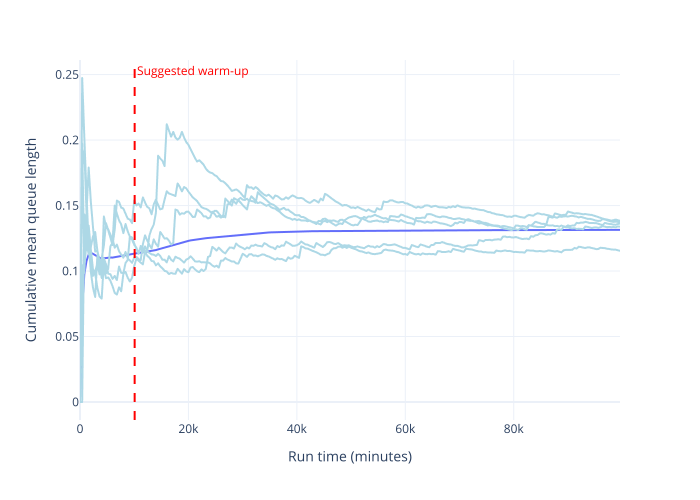

In [11]:
plot_time_series(
    audit_results=audit_results,
    metric="queue_length",
    file="choose_warmup_queue_length.png",
    warmup_time=10080
)

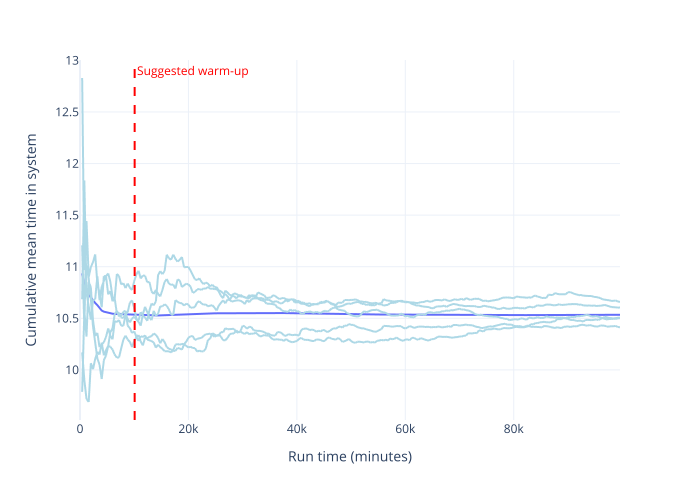

In [12]:
plot_time_series(
    audit_results=audit_results,
    metric="time_in_system",
    file="choose_warmup_time_in_system.png",
    warmup_time=10080
)

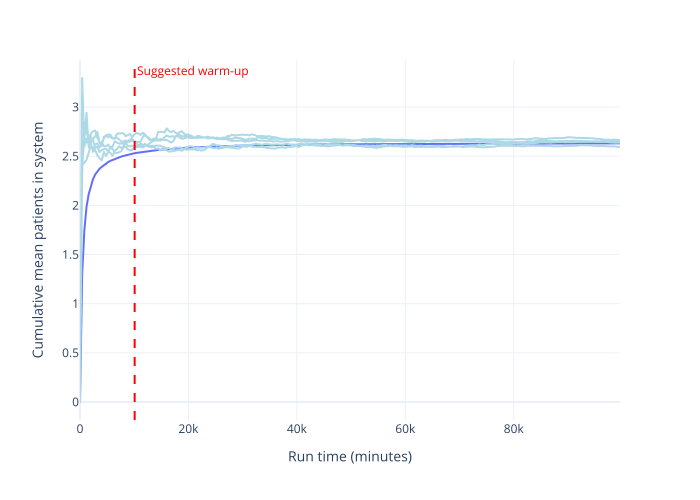

In [13]:
plot_time_series(
    audit_results=audit_results,
    metric="patients_in_system",
    file="choose_warmup_patients_in_system.png",
    warmup_time=10080
)

## Run time

In [14]:
# Get run time in seconds
notebook_end_time = time.time()
runtime = round(notebook_end_time - notebook_start_time)

# Display converted to minutes and seconds
print(f"Notebook run time: {runtime // 60}m {runtime % 60}s")

Notebook run time: 0m 28s
